## Forward CDT

Import necessary python packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

Create reference $I_0$ (uniform distribution) and a demo signal $I_1$

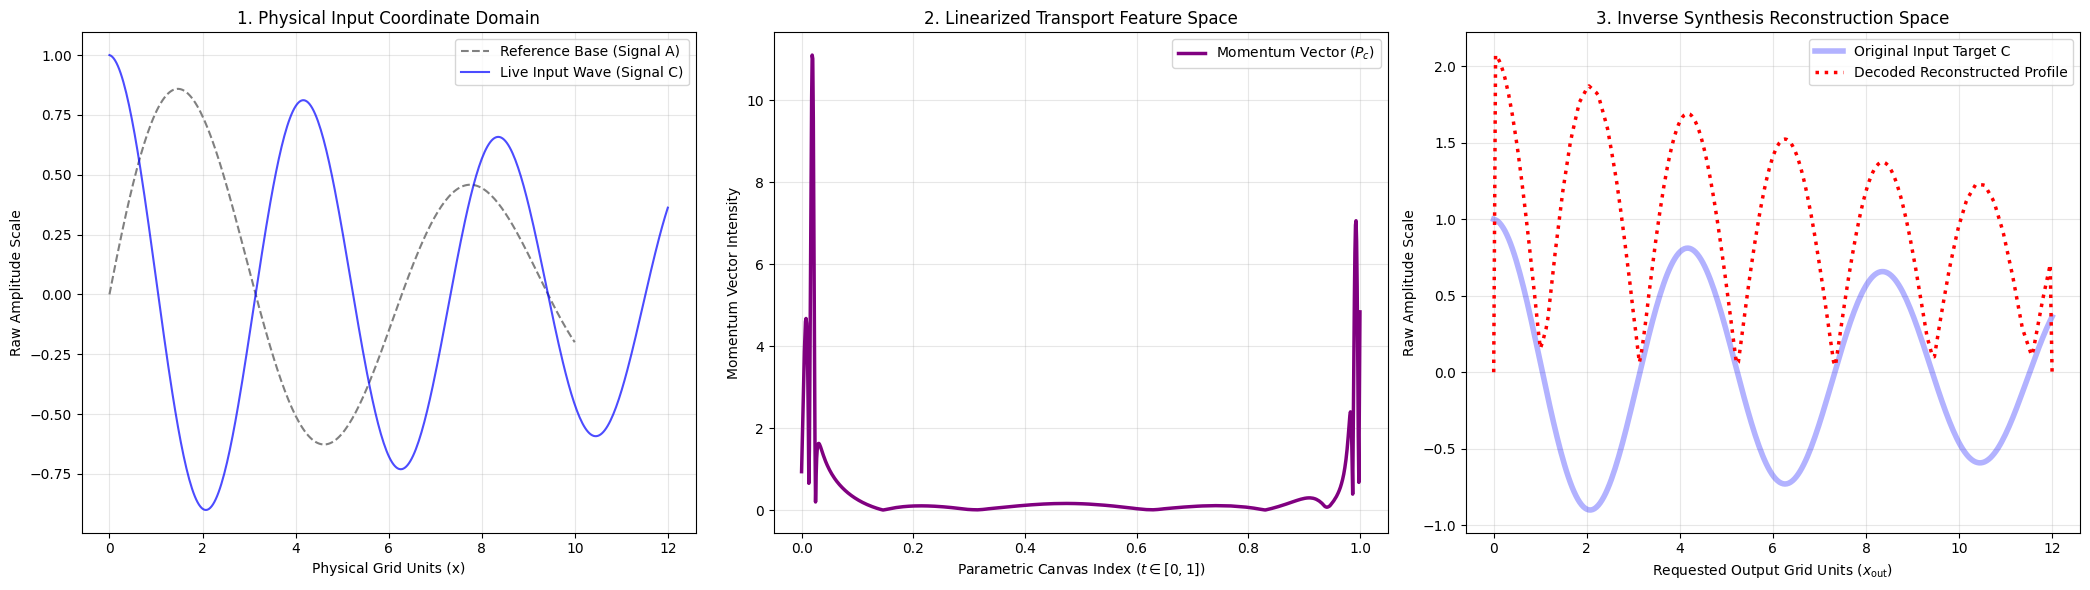

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import vmap

# Force CPU execution target for standard notebook kernels
# jax.config.update('jax_platform_name', 'cpu')



@jax.jit
def _pad_diff(array, axis=-1, clip_floor=None):
    """Computes finite differences and pads the trailing element safely."""
    d_raw = jnp.diff(array, axis=axis)
    d_padded = jnp.concatenate([d_raw, d_raw[..., -1:]], axis=axis)
    return jnp.clip(d_padded, clip_floor, None) if clip_floor is not None else d_padded

@jax.jit
def _trapcumsum(sig, delta): return jnp.cumulative_sum(0.5*(sig[..., :-1] + sig[..., 1:]) * delta, axis=-1, include_initial=True)
@jax.jit
def _trapsum(sig, delta): return jnp.sum(0.5*(sig[:-1] + sig[1:]) * delta)



@jax.jit
def _compute_master_operator_profile(t_space, Warp_fwd, Warp_inv, m1):
    """Fuses multi-perspective slopes safely, neutralizing boundary singularities."""
    grad_t = _pad_diff(t_space, clip_floor=1e-4)
    
    # Extract raw structural derivatives over the parametric space
    dfdt0 = _pad_diff(Warp_fwd) / grad_t
    dfdt1_raw = _pad_diff(Warp_inv) / grad_t
    
    # Map the inverse derivative path back onto the forward track safely
    dtdf1 = jnp.clip(jnp.interp(Warp_fwd, t_space, dfdt1_raw), 1e-5, None)
    dfdt1_mapped = 1.0 / dtdf1

    # Fused Symmetrical Velocity Matrix Average
    Velocity = 0.5 * (dfdt0 + dfdt1_mapped)
    
    # HIGHER-ORDER SMOOTHING: Apply a micro rolling average convolution filter
    # to naturally blend edge singularities without clipping metrics flat.
    #window = jnp.array([0.1, 0.2, 0.4, 0.2, 0.1]) # Gaussian smoothing kernel kernel
    # Velocity_padded = jnp.pad(Velocity, 2, mode='edge')
    #Velocity_smoothed = jnp.convolve(Velocity_padded, window, mode='valid')
    
    # return jnp.clip(Velocity_smoothed * m1, 1e-7, None)
    return jnp.clip(Velocity * m1, 1e-7, None)


VACUUM_ENERGY = 1e-2

@jax.jit
def CDT_Core_Map(t_space, y0_resampled, y1_resampled):
    dt = jnp.diff(t_space)
    # Add a continuous uniform baseline floor to protect boundary CDF derivatives
    cum0 = _trapcumsum(y0_resampled + VACUUM_ENERGY, dt)
    cum1 = _trapcumsum(y1_resampled + VACUUM_ENERGY, dt)
    m0, m1 = cum0[-1], cum1[-1]
    
    Warp_fwd = jnp.interp(cum0 / m0, cum1 / m1, t_space)
    Warp_inv = jnp.interp(cum1 / m1, cum0 / m0, t_space)
    return Warp_fwd, Warp_inv, m0, m1


@jax.jit
def CDT_Core_Forward_Pure(t_space, y_new_resampled, Warp_fwd, Phi):
    dt = jnp.diff(t_space)
    mass_new = _trapsum(y_new_resampled + VACUUM_ENERGY, dt)
    safe_mass_new = jnp.clip(mass_new, 1e-7, None)
    
    shifted_intensity = jnp.interp(Warp_fwd, t_space, y_new_resampled + VACUUM_ENERGY)
    return (shifted_intensity / safe_mass_new) * Phi


@jax.jit
def CDT_Core_Inverse_Pure(t_space, momentum_given, Warp_inv, Phi):
    rho1_target = momentum_given / Phi
    recon_sig_raw = jnp.interp(Warp_inv, t_space, rho1_target)
    
    dt = jnp.diff(t_space)
    mass_recon = _trapsum(recon_sig_raw, dt)
    return (recon_sig_raw / jnp.clip(mass_recon, 1e-7, None)) - VACUUM_ENERGY


# =========================================================================
# 2. OBJECT ENGINE WRAPPER INTERFACE
# =========================================================================

class FunctionalSignedCDTOperator:
    def __init__(self, resolution=512):
        self.resolution = resolution
        self.t_space = jnp.linspace(0.0, 1.0, resolution)
        self.Warp_fwd = self.Warp_inv = self.Phi = self.sign_meta = None

    def fit(self, x0, y0, x1, y1):
        t_ref = jnp.linspace(0.0, 1.0, x0.shape[-1])
        t_tgt = jnp.linspace(0.0, 1.0, x1.shape[-1])
        
        y0_abs = jnp.interp(self.t_space, t_ref, jnp.abs(y0))
        y1_abs = jnp.interp(self.t_space, t_tgt, jnp.abs(y1))
        
        self.sign_meta = jnp.interp(self.t_space, t_tgt, jnp.sign(y1))
        
        w_fwd, w_inv, m0, m1 = CDT_Core_Map(self.t_space, y0_abs, y1_abs)
        self.Phi = _compute_master_operator_profile(self.t_space, w_fwd, w_inv, m1)
        self.Warp_fwd, self.Warp_inv = w_fwd, w_inv
        return self

    def forward(self, x_given, y_given):
        t_given = jnp.linspace(0.0, 1.0, x_given.shape[-1])
        y_resampled = jnp.interp(self.t_space, t_given, jnp.abs(y_given))
        return CDT_Core_Forward_Pure(self.t_space, y_resampled, self.Warp_fwd, self.Phi)

    def inverse(self, momentum_given, target_grid_output):
        recon_sig_parametric = CDT_Core_Inverse_Pure(self.t_space, momentum_given, self.Warp_inv, self.Phi)
        final_sig_parametric = recon_sig_parametric * self.sign_meta
        t_out = jnp.linspace(0.0, 1.0, target_grid_output.shape[-1])
        return jnp.interp(t_out, self.t_space, final_sig_parametric).at[0].set(0.0).at[-1].set(0.0)


# =========================================================================
# 3. RUN SAMPLE LIFE-CYCLES
# =========================================================================
num_points = 1000
xref = jnp.linspace(0.0, 10.0, 256)
yref = jnp.sin(xref) * jnp.exp(-0.1 * xref)

x_B = jnp.linspace(-5.0, 15.0, 512)
y_B = 1.8 * jnp.exp(-((x_B - 5.0) ** 2) / (2 * 1.5 ** 2))

x_C = jnp.linspace(0.0, 12.0, 400)
y_C = jnp.cos(x_C * 1.5) * jnp.exp(-0.05 * x_C)

operator = FunctionalSignedCDTOperator(resolution=num_points)
operator.fit(xref, yref, x_B, y_B)
momentum_features_C = operator.forward(x_C, y_C)

x_requested_output = jnp.linspace(0.0, 12.0, 300)
reconstructed_y_C = operator.inverse(momentum_features_C, target_grid_output=x_requested_output)

# =========================================================================
# 4. DISPLAY DIAGNOSTIC DASHBOARD
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1
axes[0].plot(xref, yref, label="Reference Base (Signal A)", color="gray", linestyle="--")
axes[0].plot(x_C, y_C, label="Live Input Wave (Signal C)", color="blue", alpha=0.7)
axes[0].set_title("1. Physical Input Coordinate Domain")
axes[0].set_xlabel("Physical Grid Units (x)")
axes[0].set_ylabel("Raw Amplitude Scale")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2
axes[1].plot(operator.t_space, momentum_features_C, label="Momentum Vector ($P_c$)", color="purple", linewidth=2.5)
axes[1].set_title("2. Linearized Transport Feature Space")
axes[1].set_xlabel(r"Parametric Canvas Index ($t \in [0, 1]$)")
axes[1].set_ylabel("Momentum Vector Intensity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3
y_ground_truth_resampled = jnp.interp(x_requested_output, x_C, y_C)
axes[2].plot(x_requested_output, y_ground_truth_resampled, label="Original Input Target C", color="blue", linewidth=4, alpha=0.3)
axes[2].plot(x_requested_output, reconstructed_y_C, label="Decoded Reconstructed Profile", color="red", linestyle=":", linewidth=2.5)
axes[2].set_title("3. Inverse Synthesis Reconstruction Space")
axes[2].set_xlabel(r"Requested Output Grid Units ($x_{\text{out}}$)")
axes[2].set_ylabel("Raw Amplitude Scale")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

L2 Reconstruction Error: 0.000129


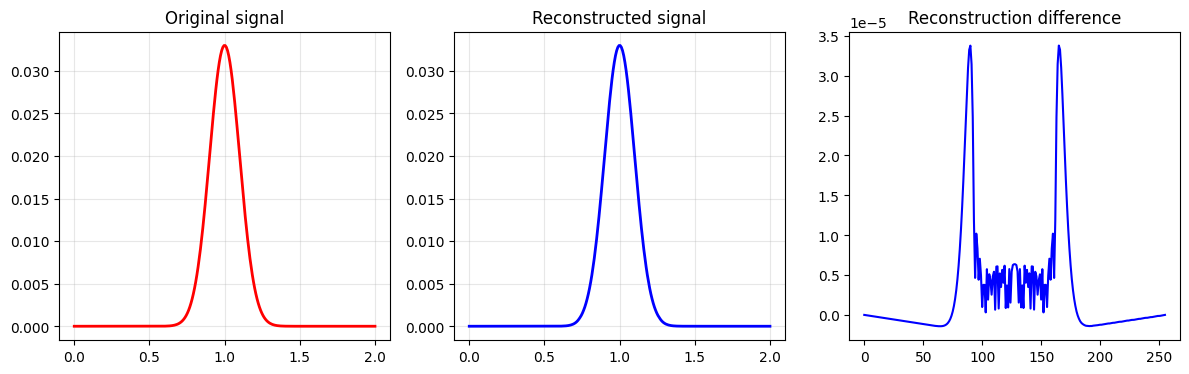

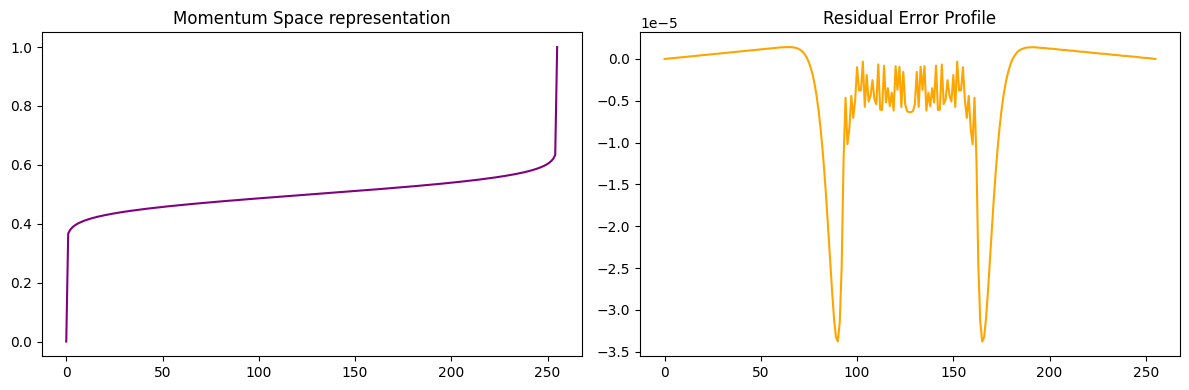

In [ ]:

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Force CPU execution target for standard notebook kernels
jax.config.update('jax_platform_name', 'cpu')

# =========================================================================
# 1. CORE OPERATIONAL MATH KERNELS (Strictly Parametric)
# =========================================================================


@jax.jit
def _trapcumsum(sig, delta): 
    return jnp.cumulative_sum(0.5 * (sig[..., :-1] + sig[..., 1:]) * delta, axis=-1, include_initial=True)

@jax.jit
def _cdf(sig, delta):
    trapsum = _trapcumsum(sig, delta)
    return jnp.where(trapsum[-1] == 0, trapsum, trapsum/trapsum[-1])

VACUUM_ENERGY = 1e-7

@jax.jit
def CDT_Core_Map(t_space, y0_resampled, y1_resampled):
    """Computes transport maps completely inside the abstract parameter domain [0, 1]."""
    dt = jnp.diff(t_space)
    cdf0 = _cdf(y0_resampled + VACUUM_ENERGY, dt)
    cdf1 = _cdf(y1_resampled + VACUUM_ENERGY, dt)
    
    Warp_fwd = jnp.interp(cdf0, cdf1, t_space)
    Warp_inv = jnp.interp(cdf1, cdf0, t_space)
    return Warp_fwd, Warp_inv

@jax.jit
def CDT_Core_Forward_Pure(t_space, y_new_resampled, Warp_fwd):
    """Maps the intensity profile directly into the warped target coordinates."""
    return jnp.clip(jnp.interp(Warp_fwd, t_space, (y_new_resampled + VACUUM_ENERGY)), 0.0, None)

@jax.jit
def CDT_Core_Inverse_Pure(t_space, momentum_given, Warp_inv):
    """Reverts the warp transformation and strips out baseline vacuum energy."""
    return jnp.clip(jnp.interp(Warp_inv, t_space, momentum_given) - VACUUM_ENERGY, 0.0, None)


# =========================================================================
# 2. OBJECT ENGINE WRAPPER INTERFACE
# =========================================================================

class FunctionalSignedCDTOperator:
    def __init__(self, resolution=None):
        self.resolution = resolution
        self.Warp_fwd = self.Warp_inv = self.sign_meta = None

    def map(self, x0, y0, x1, y1):
        if (self.resolution is None): resolution = max(x0.shape[-1], x1.shape[-1])
        else: resolution = self.resolution
        self.t_space = jnp.linspace(0.0, 1.0, resolution)

        self.t_ref = jnp.linspace(0.0, 1.0, x0.shape[-1])
        self.t_tgt = jnp.linspace(0.0, 1.0, x1.shape[-1])
        self.x1_func = x1
        
        self.sign_meta = jnp.interp(self.t_space, self.t_tgt, jnp.sign(y1))
        y0_abs = jnp.interp(self.t_space, self.t_ref, jnp.abs(y0))
        y1_abs = jnp.interp(self.t_space, self.t_tgt, jnp.abs(y1))

        self.Warp_fwd, self.Warp_inv = CDT_Core_Map(self.t_space, y0_abs, y1_abs)
        return self

    def forward(self, x_given, y_given):
        t_given = jnp.linspace(0.0, 1.0, x_given.shape[-1])
        y_resampled = jnp.interp(self.t_space, t_given, jnp.abs(y_given))
        return CDT_Core_Forward_Pure(self.t_space, y_resampled, self.Warp_fwd)

    def inverse(self, momentum_given, target_grid_output):
        recon_sig_parametric = CDT_Core_Inverse_Pure(self.t_space, momentum_given, self.Warp_inv)
        final_sig_parametric = recon_sig_parametric * self.sign_meta
        physical_x1_grid = jnp.interp(self.t_space, self.t_tgt, self.x1_func)
        return jnp.interp(target_grid_output, physical_x1_grid, final_sig_parametric)


# =========================================================================
# 3. RUN SAMPLE LIFE-CYCLES
# =========================================================================
num_points = 256  
xref = jnp.linspace(0.0, 2.0, 256)
yref = jnp.zeros((256,)) + 0.1 

x_B = jnp.linspace(0.0, 2.0, 256)
y_B = 0.033 * jnp.exp(-((x_B - 1.0) ** 2) / (2 * 0.1 ** 2))

operator = FunctionalSignedCDTOperator(resolution=num_points)
operator.map(xref, yref, x_B, y_B)

momentum_features_B = operator.forward(x_B, y_B)
reconstructed_y_B = operator.inverse(momentum_features_B, target_grid_output=x_B)

ydiff = jnp.linalg.norm(reconstructed_y_B - y_B, ord=2)
print(f"L2 Reconstruction Error: {ydiff:.6f}")

# =========================================================================
# 4. DISPLAY DASHBOARD
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(x_B, y_B, label="Original Target B", color="red", linewidth=2)
axes[0].set_title("Original signal")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_B, reconstructed_y_B, label="Decoded Reconstruction", color="blue", linewidth=2)
axes[1].set_title("Reconstructed signal")
axes[1].grid(True, alpha=0.3)


axes[2].plot(y_B-reconstructed_y_B, 'b-')
axes[2].set_title('Reconstruction difference')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(operator.Warp_fwd, color="purple")
axes[0].set_title("Momentum Space representation")

axes[1].plot(reconstructed_y_B - y_B, color="orange")
axes[1].set_title("Residual Error Profile")
plt.tight_layout()
plt.show()

## Tools

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functools


# Functional utilities
def IsSingle(v): return not isinstance(v, (list, tuple)) or hasattr(v, 'ndim') or isinstance(v, (str, dict))
def Broadcast(v,N): return [v]*N if IsSingle(v) else [*v]*N if len(v)==1 else v
def InvokeParams(func, params): 
    if (params is not None): return (
        func(params) if IsSingle(params) else
        func(*params[0],**params[1]) if (isinstance(params,tuple) and len(params)==2) else
        func(*[v for v in params if not isinstance(v,dict)],
            **next((kvp for kvp in params if isinstance(kvp,dict)), {})
        )
    )


def Accessor(data, i): return (
    None if (data is None) else 
    data if (IsSingle(data) or len(data)==0) else 
    data[i%len(data)] if (not isinstance(data, tuple)) else
    tuple(Accessor(item,i) for item in data)
)



def jit_static(*args, **kwargs):
    """Jit a function, preserve types, and make it a staticmethod."""
    return staticmethod(jit_func)
def jit_func(*args, **kwargs):
    """Wrap a function with jit and optional args."""
    def wrapper(func): return functools.wraps(func)(jax.jit(func, *args, **kwargs))
    return wrapper





@jax.jit
def _trapcumsum(xsig, ysig):
    return jnp.cumulative_sum((0.5*(ysig[...,:-1]+ysig[...,1:])*jnp.diff(xsig, axis=-1)), axis=-1, include_initial=True)

@jax.jit
def _vmapinterp(x, xf,yf):
    return jnp.interp(x, xf, yf, left=yf[0], right=yf[-1])

@jax.jit
def _cdf(x,y):
    CDF = _trapcumsum(x,y)
    M = CDF[...,-1:]
    return jnp.where(M != 0, CDF/M, CDF)
    








# def Accessor2D(data, i,j)
# def AccessorND(data, *idxs):


def BuildSubplots(nrows,ncols, functionmap, figsize=(10, 10), col_firs=True):
    fig, ax = plt.subplots(nrows,ncols, figsize=figsize, layout="tight")
    for c in range(ncols):
        for r in range(nrows):
            axes = ax[c] if (nrows == 1) else ax[r] if (ncols == 1) else ax[r,c]
            i,j = (c,r) if (col_firs) else (r,c) 
            for func, params in functionmap.items():
                arg = Accessor(Accessor(params[0], i),j)
                kwargs = {key:Accessor(Accessor(val, i),j) for key,val in params[1].items()}
                if IsSingle(arg): arg = [arg]
                func(axes, *arg, **kwargs)
    plt.show()
    return fig, ax


In [5]:




@jax.jit
def CDT_Forward(x0,y0, x1,y1):
    CDF0, CDF1 = _trapcumsum(x0, y0), _trapcumsum(x1, y1)
    CDF0 /= CDF0[-1]
    CDF1 /= CDF1[-1]
    mapg = _vmapinterp(CDF1, CDF0, x0)
    return mapg, jnp.sum(y1, axis=-1, keepdims=True)

@jax.jit
def CDT_Inverse(x0,y0,map,mass):
    warped = _vmapinterp(map, x0, y0) * jnp.gradient(map, axis=-1)
    warped = warped / jnp.sum(warped, axis=-1, keepdims=True)
    return warped * mass



@jax.jit
def CDT_Forward0(x0,y0, x1,y1):
    CDF0 = _trapcumsum(x0, y0)
    CDF1 = _trapcumsum(x1, y1)
    CDF0 /= CDF0[-1]
    CDF1 /= CDF1[-1]
    mapg = _vmapinterp(CDF1, CDF0, x0)
    

    return mapg, jnp.sum(y1, axis=-1, keepdims=True)

@jax.jit
def CDT_Inverse0(x0,y0,map,mass):
    J = jnp.maximum(jnp.gradient(map, x0, axis=-1), 1e-7)
    warped = _vmapinterp(map, x0, y0) * J
    warped = warped / jnp.sum(warped, axis=-1, keepdims=True)
    
    return warped * mass


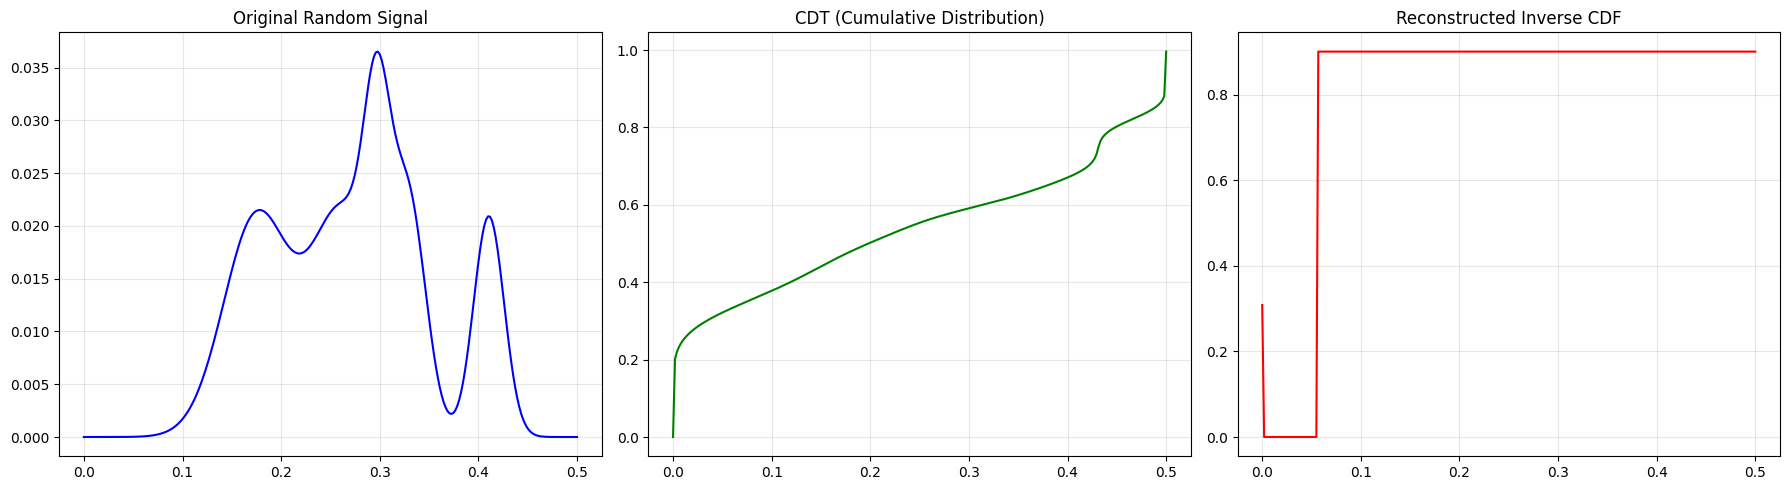

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Original Random Signal'}>,
        <Axes: title={'center': 'CDT (Cumulative Distribution)'}>,
        <Axes: title={'center': 'Reconstructed Inverse CDF'}>],
       dtype=object))

In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from pytranskit.optrans.continuous.transforms import CDT
from pytranskit.optrans.continuous import CDT as CDTold

# --- 1. Signal Generation ---
def generate_random_gmm(key, N, num_components=3):
    """
    Generates a sum of random Gaussians.
    key: jax.random.PRNGKey
    N: number of points
    num_components: How many Gaussians to sum
    """
    # Split the key to generate different parameters
    k1, k2 = jax.random.split(key)
    
    # Generate random mus and sigmas
    mus = jax.random.uniform(k1, shape=(num_components,), minval=0.1, maxval=0.9)
    sigmas = jax.random.uniform(k2, shape=(num_components,), minval=0.02, maxval=0.08)
    
    # Generate the signal
    x = jnp.linspace(0, 1, N)
    # Broadcasting: (num_components, 1) - (1, N) -> (num_components, N)
    exponent = -((x[None, :] - mus[:, None])**2) / (2 * sigmas[:, None]**2)
    gaussians = jnp.exp(exponent)
    
    signal = gaussians.sum(axis=0)
    return (signal / jnp.sum(signal))


# --- 3. Execution ---
N = 256
batch_size = 100


xref = jnp.linspace(0.0, 2.0, 256) * 4.5
yref = (jnp.zeros(256) + 0.1) * 8
yref.at[0].set(1)

xsig = jnp.linspace(0, 1, N) / 2
ysig = generate_random_gmm(jax.random.PRNGKey(42), N, 5) * 3


cdt = CDT()
transformed_signal, invsig = cdt.find_mapping(xref, yref, xsig, ysig)
reconstructed_signal = cdt.apply_inverse(xref, yref)

cdtold = CDTold()
transformed_signal_old = cdtold.forward(xref, yref, xsig, ysig)[0]
reconstructed_signal_old = cdtold.inverse(transformed_signal_old, yref, xsig)

# def _trapvalue(xsig, ysig)





BuildSubplots(1, 3, figsize=(18,5), col_firs=True, functionmap= {
        plt.Axes.grid: ([True], {'alpha':0.3}),
        plt.Axes.set_title: ([
            "Original Random Signal",
            "CDT (Cumulative Distribution)",
            "Reconstructed Inverse CDF"
        ], {}
        ),
        plt.Axes.plot: ([
            (xsig, ysig),
            (xsig, transformed_signal),
            (xsig, reconstructed_signal)
        ], {'color':['blue', 'green', 'red']})
    }              
)



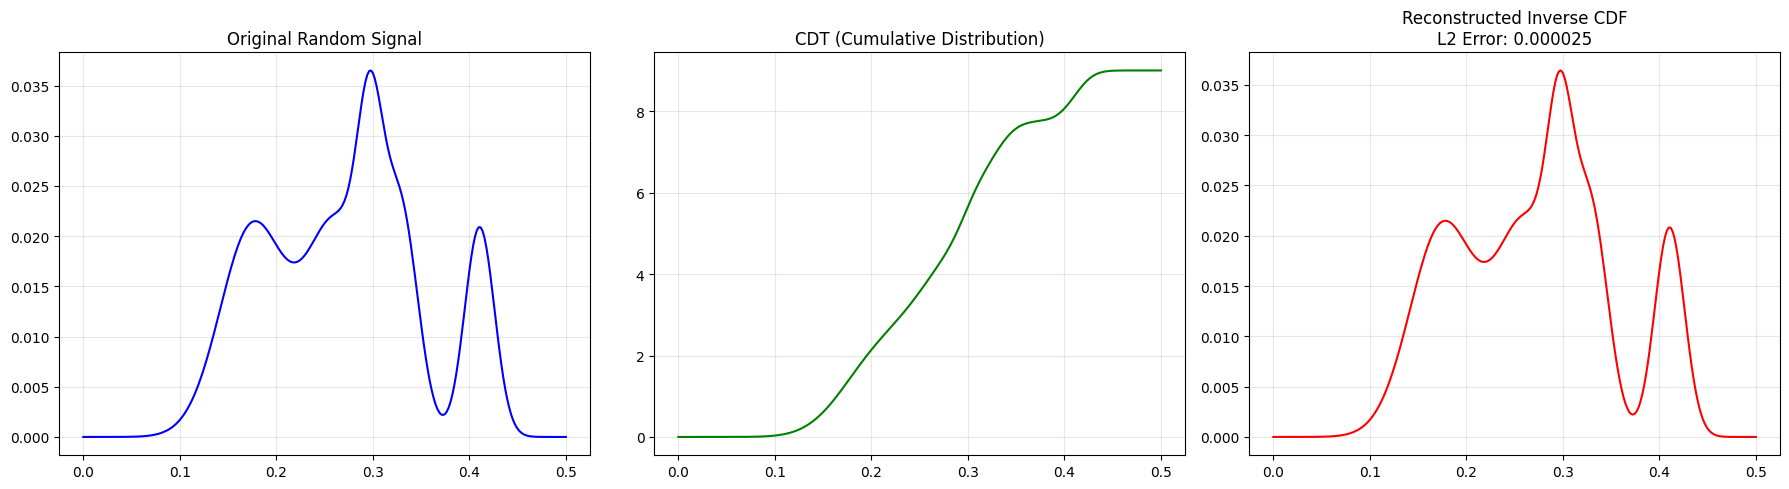

<Figure size 640x480 with 0 Axes>

In [6]:




transformed_signal, mass1 = CDT_Forward(xref, yref, xsig, ysig)
transformed_signal2, mass2 = CDT_Forward0(xref, yref, xsig, ysig)
reconstructed_signal = CDT_Inverse(xref, yref, transformed_signal, mass1)
reconstructed_signal2 = CDT_Inverse0(xref, yref, transformed_signal2, mass2)


# Calculate L2 Error
error = jnp.sqrt(jnp.mean((ysig - reconstructed_signal)**2))



BuildSubplots(1, 3, figsize=(18,5), col_firs=True, functionmap= {
        plt.Axes.grid: ([True], {'alpha':0.3}),
        plt.Axes.set_title: ([
            "Original Random Signal",
            "CDT (Cumulative Distribution)",
            f"Reconstructed Inverse CDF\nL2 Error: {error:.6f}"
        ], {}
        ),
        plt.Axes.plot: ([
            (xsig, ysig),
            (xsig, [transformed_signal, transformed_signal2]),
            (xsig, [reconstructed_signal, reconstructed_signal2])
        ], {'color':['blue', 'green', 'red']})
    }              
)

plt.tight_layout()
plt.show()

In [138]:






# def make_batch_compatible(func_1d):
#     """Decorator to make a 1D function accept arbitrary batch shapes."""
#     @jax.jit
#     def batched_func(src, tgt):
#         if (src.shape == tgt.shape): return src, tgt

#         # Finds the unified batch grid excluding the last dimention (features)
#         batch_shape = jnp.broadcast_shapes(src.shape[:-1], tgt.shape[:-1])

#         def flatten_batch(arr, bshape):
#             return jnp.broadcast_to(arr, bshape+(arr.shape[-1],)).reshape(-1, arr.shape[-1])
        
#         def inflate_batch(flat, bshape):
#             return flat.reshape(bshape + (flat.shape[-1],))

#         bc_src = jnp.broadcast_to(src, batch_shape+(src.shape[-1],))
#         bc_tgt = jnp.broadcast_to(tgt, batch_shape+(tgt.shape[-1],))
#         flat_src = bc_src.reshape(-1, bc_src.shape[-1])
#         flat_tgt = bc_tgt.reshape(-1, bc_tgt.shape[-1])

#         # 1. Capture target metadata
#         orig_shape = tgt.shape
#         feature_dim = orig_shape[-1]
#         batch_shape = orig_shape[:-1]
#         # Calculate the total flat batch size (e.g., 16 * 10 = 160)
#         total_batch_size = int(jnp.prod(jnp.array(batch_shape)))

#         # If input is strictly 1D, just run the 1D function directly
#         if len(input_shape) == 1:
#             return func_1d(*args)
            
#         batch_shape = input_shape[:-1]
#         feature_dim = input_shape[-1]
        
#         # Flatten all leading batch dimensions into a single dimension
#         flat_args = []
#         for arg in args:
#             # If an argument is a scalar mass or has fewer dimensions, handle it
#             if arg.ndim <= len(batch_shape):
#                 flat_args.append(arg.reshape(-1, *arg.shape[len(batch_shape):]))
#             else:
#                 flat_args.append(arg.reshape(-1, feature_dim))
                
#         # Vectorize the 1D function over the newly flattened batch axis (axis=0)
#         vmapped_func = jax.vmap(func_1d)
#         outputs = vmapped_func(*flat_args)
        
#         # Reshape outputs back to the original batch configuration
#         if isinstance(outputs, tuple):
#             return tuple(out.reshape(batch_shape + out.shape[1:]) for out in outputs)
#         return outputs.reshape(batch_shape + outputs.shape[1:])
        
#     return batched_func















In [139]:
import math
N = 300

## Gaussian distribution
t0 = np.linspace(0,1,N) # Domain of the reference
#s0 = np.exp(-10*(t0-0.5)**2)/np.sqrt(2*np.pi)
s0 = np.ones(N)
s0 = s0/s0.sum()

t = np.linspace(0,0.5,N) # Domain of the input signal
def signal_gabor(t):
    w = 10
    tm = t[-1]/2
    s = np.real(math.pi**-0.25 * np.exp(4*math.pi*1j*w*(t-tm)) * np.exp(-120*((t-tm)**2)))
    return s

s = signal_gabor(t)
s_CDF = np.cumsum(s)






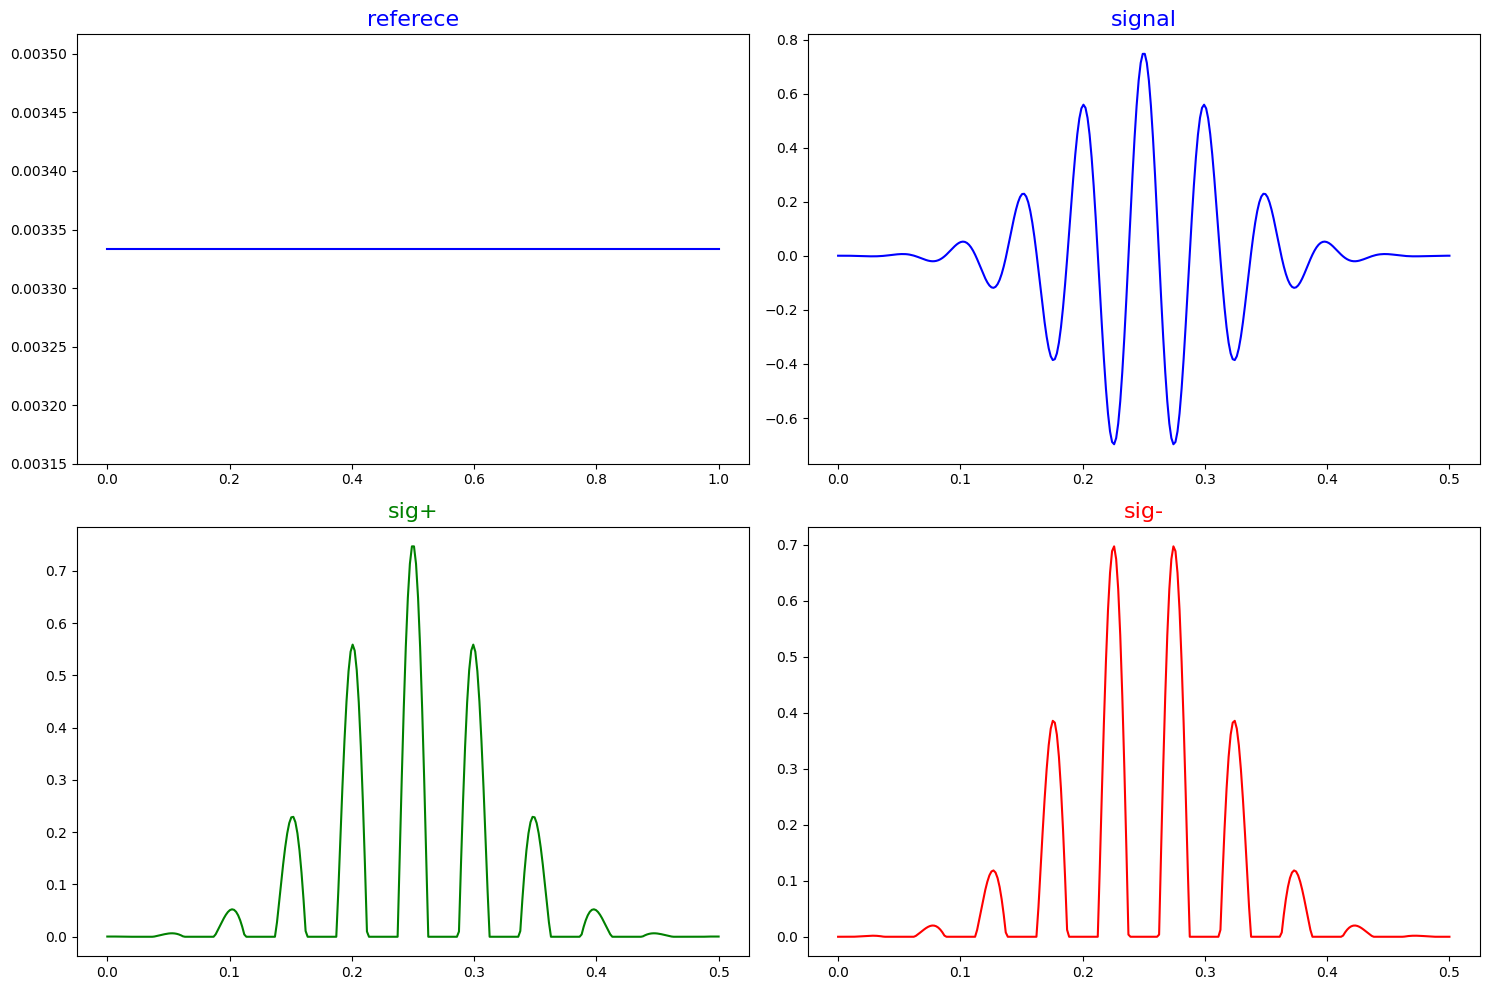

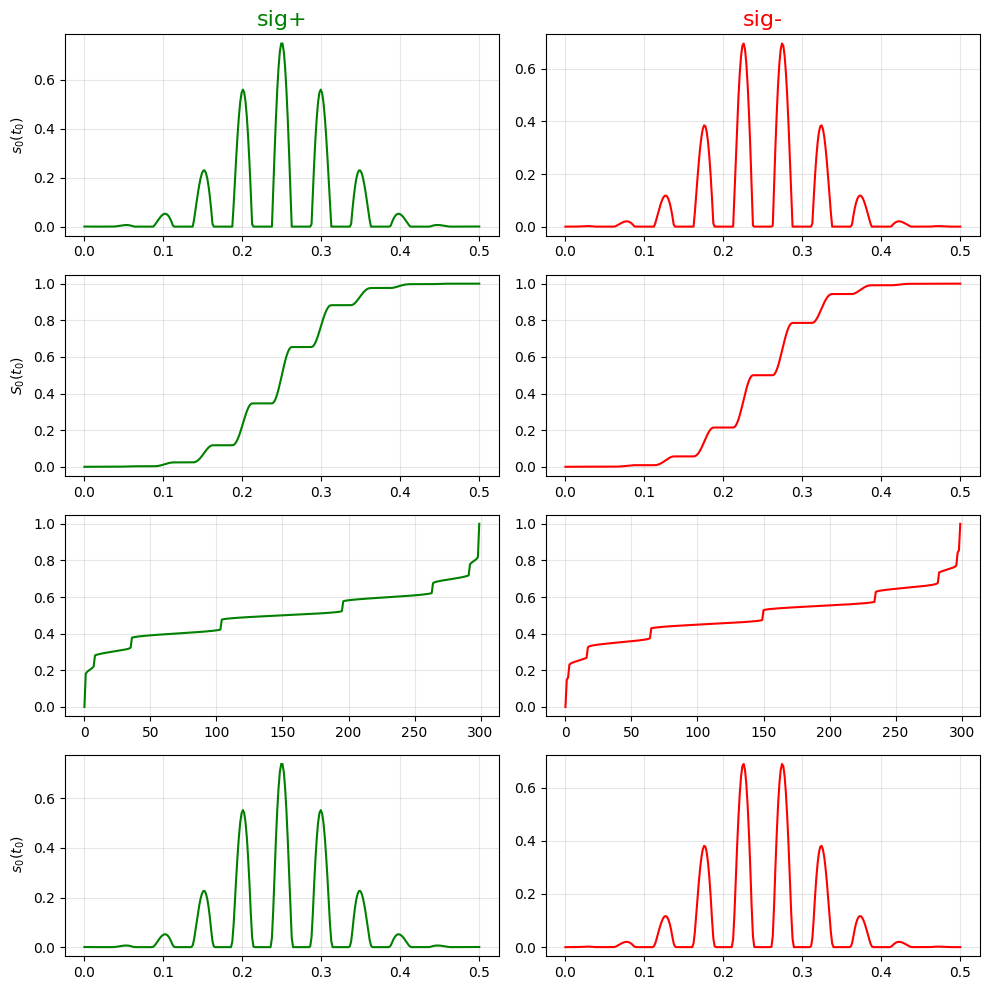

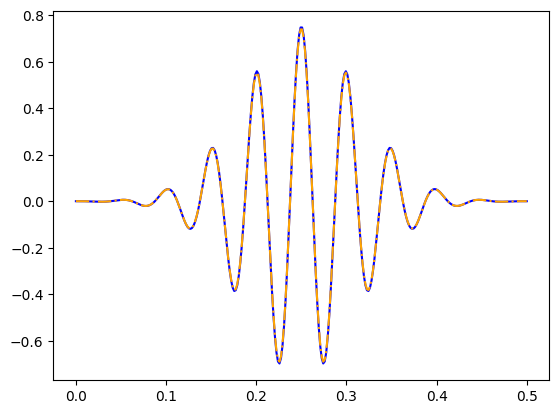

In [140]:


def SplitSignal(signal):
    return (jnp.where(signal > 0, signal, 1e-9), jnp.where(signal < 0, -signal, 1e-9))

ysigpos, ysigneg = SplitSignal(s)

pshat, pmhat = CDT_Forward0(t0, s0, t, ysigpos)
nshat, nmhat = CDT_Forward0(t0, s0, t, ysigneg)

pshat_inv = jnp.interp(jnp.linspace(0,1, pshat.shape[-1]), pshat, t)
pshat_inv /= pshat_inv[-1]
nshat_inv = jnp.interp(jnp.linspace(0,1, nshat.shape[-1]), nshat, t)
nshat_inv /= nshat_inv[-1]


psrecon = CDT_Inverse0(t0,s0, pshat, pmhat)
nsrecon = CDT_Inverse0(t0,s0, nshat, nmhat)





BuildSubplots(2, 2, figsize=(15,10), col_firs=False, functionmap= {
        plt.Axes.grid: ([False], {}),
        plt.Axes.set_title: (
            [["referece", "signal"],["sig+", "sig-"]], 
            {'fontsize':16, 'color':[['blue','blue'],['green','red']]}
        ),
        plt.Axes.plot: ([
            [(t0, s0), (t, s)],
            [(t, ysigpos), (t, ysigneg)]
        ], {'color':[['blue', 'blue'], ['green', 'red']]})
    }              
)


BuildSubplots(4,2, col_firs=True, functionmap={
    plt.Axes.grid: (
        [True], 
        {"alpha":0.3}
    ), 
    plt.Axes.set_title: ([
        ["sig+",None,None,None], 
        ["sig-",None,None,None]], 
        {'color':['green','red'], 'fontsize':16}
    ),
    plt.Axes.set_ylabel: ([
        ["$s_0(t_0)$", "$S_0(t_0)$", None, "$~s_0(t_0)$"], 
        [None, None, None, None]], 
        {}
    ),
    plt.Axes.plot: ([
        [(t, ysigpos), (t, pshat), (pshat_inv,), (t, psrecon)],
        [(t, ysigneg), (t, nshat), (nshat_inv,), (t, nsrecon)]], 
        {'color': ['green', 'red'] }
    )
})




plt.show()

# sigrecon = psrecon - nsrecon

plt.plot(t, s, color='blue')
plt.plot(t, psrecon - nsrecon, color='orange', linestyle='dashdot')
plt.show()
# plt.plot(t, s-sigrecon)

In [ ]:
def CDT_Forward_Full(x0,y0, x1,y1):
    print(x0.shape, y0.shape, x1.shape, y1.shape)
    N = x1.shape[-1]
    # CDF has range of [0,1], same domains.
    cdf0 = _cdf(x0, y0)
    cdf1 = _cdf(x1, y1)
    t0 = jnp.linspace(0,1, x0.shape[-1])
    t1 = jnp.linspace(0,1, x1.shape[-1])
    MAPF = _vmapinterp(cdf0, cdf1, t1) # x1 = CDF1_inv(CDF0(x0)) or f_fwd
    MAPG = _vmapinterp(cdf1, cdf0, t0) # x0 = CDF0_inv(CDF1(x1)) or f_inv
    MASS = jnp.sum(y1, axis=-1, keepdims=True)
    return (MAPF, MAPG), (MASS, N)

def CDT_Inverse_Full(x0,y0, maps,meta):
    
    x1 = jnp.linspace(0,1, maps[0].shape[-1])
    # x1 = newx if newx is not None else jnp.linspace(0,1, maps[0].shape[-1])
    JF = jnp.clip(jnp.gradient(maps[0], x1, axis=-1), 1e-7)
    warpedf = _vmapinterp(x1, maps[0], y0/JF)
    warpedf /= jnp.sum(warpedf, axis=-1, keepdims=True)
    
    # maps = (maps[0], _vmapinterp(jnp.linspace(0,1, x0.shape[-1]), maps[1], maps[1]))
    JG = jnp.clip(jnp.gradient(maps[1], x0, axis=-1), 1e-7)
    warpedg = _vmapinterp(maps[1], x0, y0) * JG
    warpedg /= jnp.sum(warpedg, axis=-1, keepdims=True)

    
    return warpedf*meta[0], warpedg*meta[0]




(20000,) (20000,) (20000,) (20000,)
(20000,) (20000,) (20000,) (20000,)


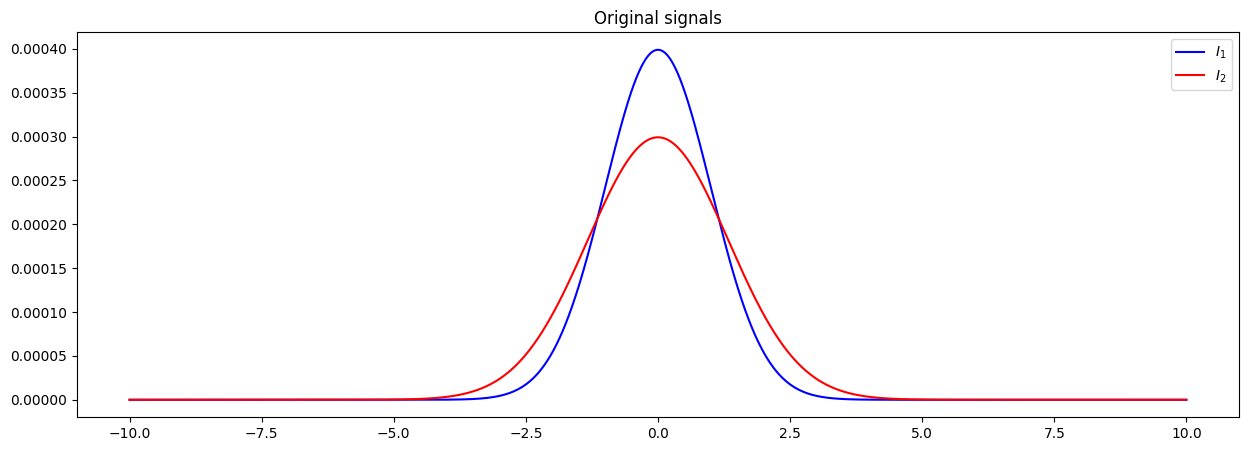

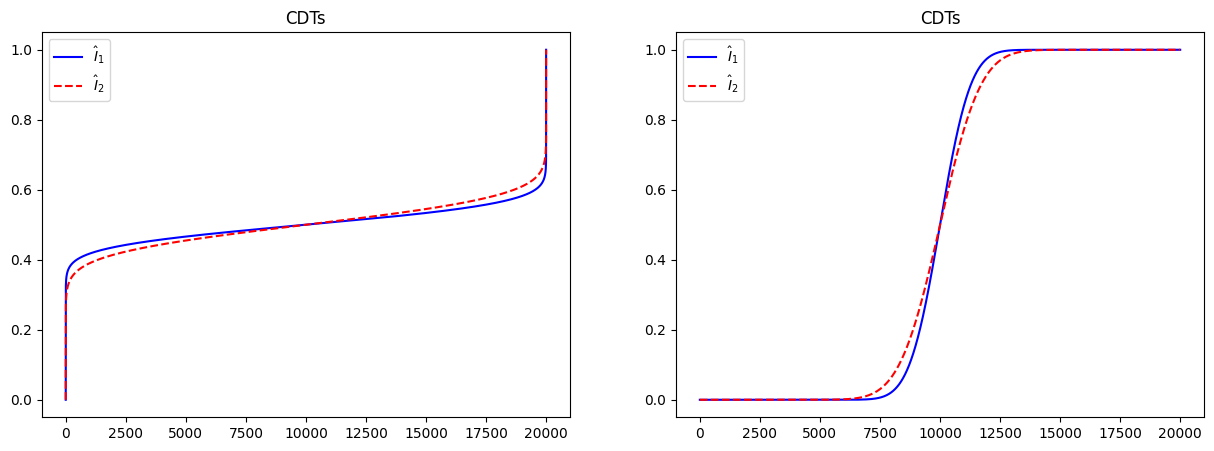

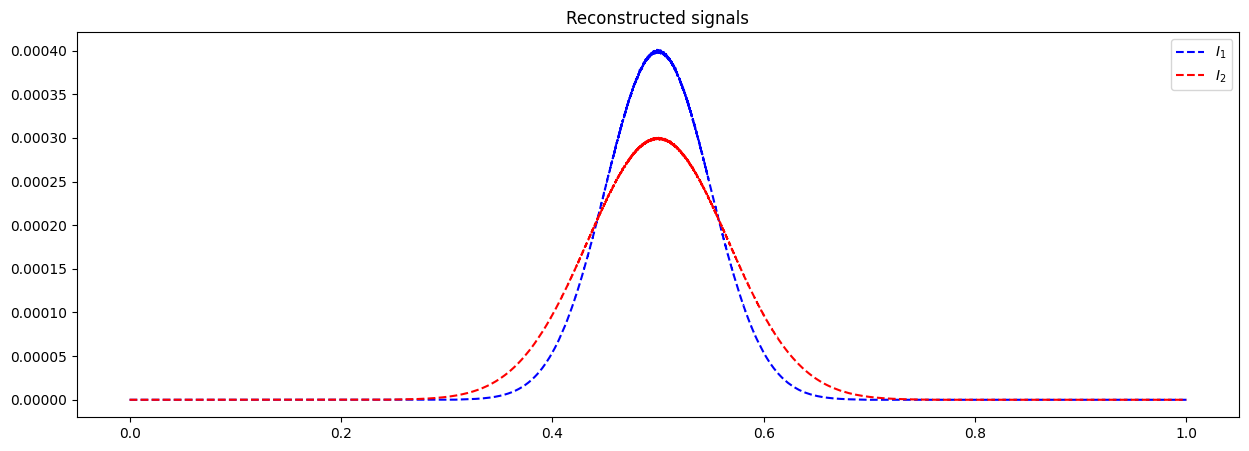

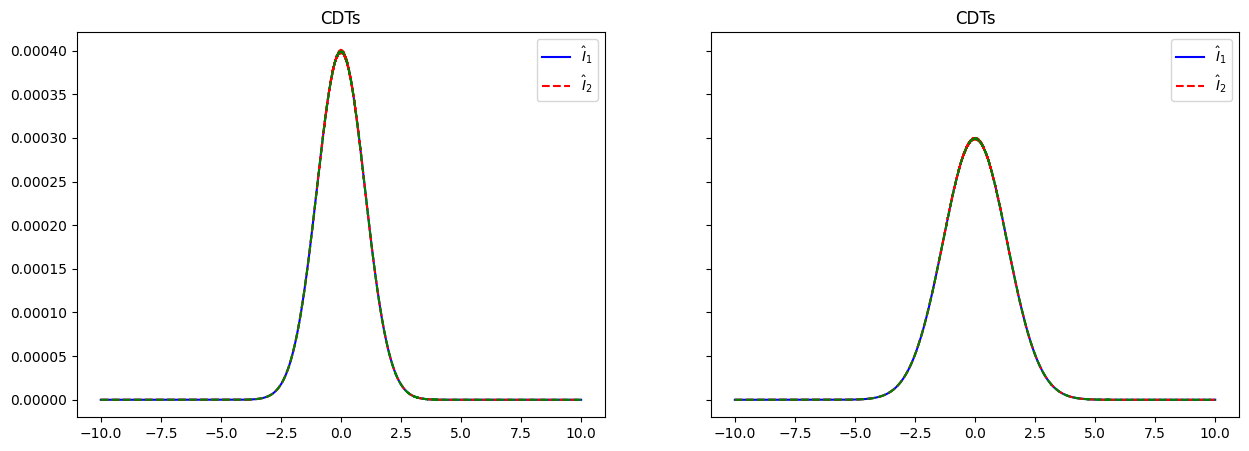

In [201]:
from scipy.stats import norm
epsilon = 1e-7
x = np.arange(-10,10,0.001)

N=len(x)

x0 = np.linspace(0, 1, round(N))
I0= np.ones(x0.size)

I1 = norm.pdf(x,0,1)
# create a scaled version of I1; i.e. I2(t) = I1(alpha*t)
alpha = 0.75
I2 = np.interp(alpha*x, x, I1)

# Convert signals to strictly positive PDFs
I0 = abs(I0) + epsilon
I0 = I0/I0.sum()
I1 = abs(I1) + epsilon
I1 = I1/I1.sum()
I2 = abs(I2) + epsilon
I2 = I2/I2.sum()


MAPS1, META1 = CDT_Forward_Full(x0,I0, x,I1)
MAPS2, META2 = CDT_Forward_Full(x0,I0, x*alpha,I2)
I1_hat0, I1_hat1 = MAPS1
I2_hat0, I2_hat1 = MAPS2
RECONS1 = CDT_Inverse_Full(x0,I0, MAPS1, META1)
RECONS2 = CDT_Inverse_Full(x0,I0, MAPS2, META2)


#Plot the signals and CDTs
fig, ax = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(15,5))
ax.plot(x, I1, 'b-')
ax.plot(x, I2, 'r-')
ax.set_title('Original signals')
ax.legend([r'$I_1$',r'$I_2$'])


fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,5))
ax[0].plot(I1_hat0, 'b-')
ax[0].plot(I2_hat0, 'r--')
ax[0].set_title('CDTs')
ax[0].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])

ax[1].plot(I1_hat1, 'b-')
ax[1].plot(I2_hat1, 'r--')
ax[1].set_title('CDTs')
ax[1].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])

#Plot the signals and CDTs
fig, ax = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(15,5))
ax.plot(x0, RECONS1[0], 'b--')
ax.plot(x0, RECONS2[0], 'r--')
ax.set_title('Reconstructed signals')
ax.legend([r'$I_1$',r'$I_2$'])



fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(15,5))
ax[0].plot(x, I1, 'b-')
ax[0].plot(x, RECONS1[0], 'r--')
ax[0].plot(x, RECONS1[1], 'g--')
ax[0].set_title('CDTs')
ax[0].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])

ax[1].plot(x, I2, 'b-')
ax[1].plot(x, RECONS2[0], 'r--')
ax[1].plot(x, RECONS2[1], 'g--')
ax[1].set_title('CDTs')
ax[1].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])
plt.show()

In [202]:
N=250
x0 = np.linspace(0, 1, N)
I0= np.ones(x0.size)
x=np.linspace(0, 2, N)
mu=x[len(x)-1]/2.
sigma=0.1
I1=1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2)/(2*sigma**2))

#Convert signals to strictly positive PDFs:
epsilon = 1e-7
I0 = abs(I0) + epsilon
I0 = I0/I0.sum()
I1 = abs(I1) + epsilon
I1 = I1/I1.sum()


(250,) (250,) (250,) (250,)


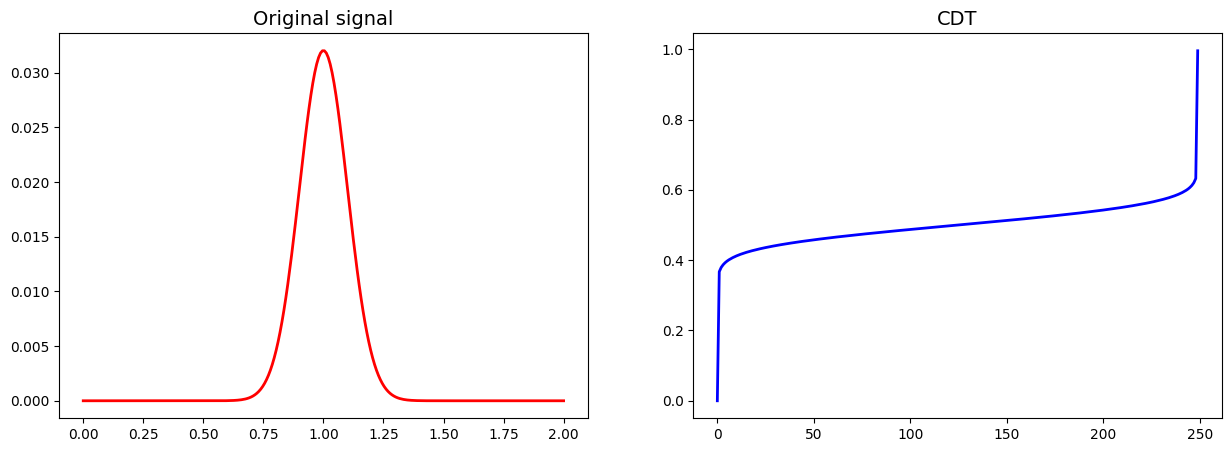

In [203]:
# The transport map and the mass to preserve
STATE = CDT_Forward_Full(x0,I0, x,I1)
MAPS, MASS = STATE
xtilde = x0


# Plot I1 and I1_hat
fontSize=14
fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,5))
ax[0].plot(x, I1, 'r-', linewidth=2)
ax[0].set_title('Original signal',fontsize=fontSize)

ax[1].plot(MAPS[0], 'b-',linewidth=2)
# ax[1].plot(I0_hat, 'b-',linewidth=2)
ax[1].set_title('CDT',fontsize=fontSize)
plt.show()

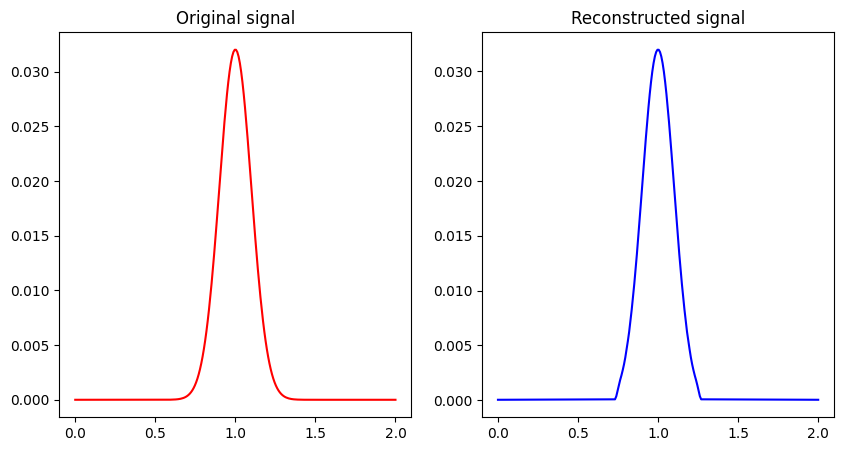

In [204]:
I1_recon = CDT_Inverse_Full(x0, I0, MAPS, MASS)




# Plot I1 and I1_recon
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False, figsize=(10,5))
ax[0].plot(x,I1, 'r-')
ax[0].set_title('Original signal')

ax[1].plot(x,I1_recon[0], 'b-')
ax[1].set_title('Reconstructed signal')
plt.show()